# 06 — Model Comparison

Five models, chosen on structural grounds before looking at a single
result: this is tabular, structured data (~48k rows, one numeric
target) — the well-established strong default for that shape of
problem is tree-based ensembles, not deep learning (which generally
doesn't beat well-tuned gradient boosting at this scale). The five:

1. **Ridge regression** — not a repeat of `04`'s plain linear model.
   This specifically tests whether the baseline's weakness was a lack
   of regularization/flexibility rather than linearity itself, and
   doubles as the interpretability anchor for the whole comparison
   (coefficients are directly readable, unlike any tree ensemble).
2. **Random Forest** — bagged trees, low tuning effort, hard to
   badly overfit, gives feature importances directly, a natural
   non-linear step up from Ridge.
3. **LightGBM** — the strongest default for tabular regression in
   practice; sequential error-correction rather than independent
   averaging usually wins on data shaped like this. Chosen over
   XGBoost specifically because it trains faster via histogram-based,
   leaf-wise growth — a minor, not load-bearing, choice between two
   versions of the same underlying technique.
4. **HistGradientBoostingRegressor** — same family as LightGBM, but
   with *native* categorical support, meaning `pickup`/`delivery`/
   `equipment` can be passed as raw categories with zero encoding.
   A direct, empirical test of "does skipping the encoding decision
   entirely beat engineering around it."
5. **k-Nearest Neighbors** — the deliberate outlier. A non-parametric,
   instance-based method with no assumption about functional form at
   all, included as a sanity check on how much of `posted_rate` is
   driven by proximity in feature space vs. a clean functional
   relationship. Expected to lose to the tree ensembles — a
   documented "expected to lose and here's why" is more rigorous than
   only testing models expected to win.

**Hyperparameter search**: `GridSearchCV` with `TimeSeriesSplit` as
the internal CV strategy, run on `train` only — not sklearn's default
shuffled KFold, which would reintroduce exactly the leakage problem
the roadmap already ruled out for the outer split. `tune` is the
independent set every model is finally compared on; `test` (October)
stays untouched until the single number that goes in the report.

**Revision note**: the grids below were widened after the first run
of this notebook. That first pass used narrow, compute-budget-driven
grids (as little as one tuned hyperparameter for Ridge, 2-3 values
per param elsewhere) because of a 1-CPU sandbox constraint during
development — not because those grids were judged sufficient. Ridge
in particular only had `alpha` tuned, never its regularization type,
which is a real gap given Ridge won that run; `07_model_comparison.ipynb`
addresses that gap directly with Lasso and Elastic Net as separate
models. The wider grids here are sized for a full multi-core machine,
not this sandbox — see the per-model markdown for what changed and
why. Because the search space changed, **the specific numbers in the
Summary section below are from the original narrow-grid run and will
change once this notebook is re-executed** — treat every number below
as provisional until you rerun it locally.

**Interpretability and confidence, given how this model gets used**:
this is a decision-support number a person looks at, not an automated
price. Two things follow from that, addressed at the end of this
notebook rather than baked into `validation_predictions.csv` itself
(the assessment's output format is a fixed two-column CSV with no
room for a range) — SHAP explanations for the winning tree model, and
residual-bucket confidence bands, both described as capabilities for
a future interface (alongside the dashboard idea from the roadmap)
rather than built into the graded deliverable.

In [35]:
import logging
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm as lgb

from src import config, data, evaluate, features, viz

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
viz.apply_theme()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

STAGE = "modeling"

INFO src.viz: Applied Spotter brand theme to matplotlib rcParams


## Data, split, and features — identical to `05_feature_engineering.ipynb`

Same chronological split, same three encoders fit on `train` only,
same `build_features` call applied identically to every slice. No
model below gets a different or easier split than another.

In [36]:
train_test = data.load_train_test_cleaned()
train, tune, test = data.chronological_split(train_test)

pickup_encoder = features.fit_target_encoder(train, "pickup", config.TARGET_COL)
delivery_encoder = features.fit_target_encoder(train, "delivery", config.TARGET_COL)
lane_encoder = features.fit_lane_encoder(train, "pickup", "delivery", config.TARGET_COL)

train_feat = features.build_features(train, pickup_encoder, delivery_encoder, lane_encoder)
tune_feat = features.build_features(tune, pickup_encoder, delivery_encoder, lane_encoder)
test_feat = features.build_features(test, pickup_encoder, delivery_encoder, lane_encoder)

print(f"train: {len(train_feat):,}, tune: {len(tune_feat):,}, test: {len(test_feat):,} (test untouched)")

INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\processed\train_test.csv
INFO src.data: Loaded train_test.csv: 48000 rows, 14 columns
INFO src.data: Chronological split: train=33718 (2025-01-01-2025-07-31), tune=9429 (2025-08-01-2025-09-30), test=4853 (2025-10-01-2025-10-31)
INFO src.features: Fit target encoder for pickup on 33718 rows, 64 categories, global_mean=2373.79
INFO src.features: Fit target encoder for delivery on 33718 rows, 64 categories, global_mean=2373.79
INFO src.features: Fit lane encoder on 33718 rows, 3984 distinct lanes, global_mean=2373.79
INFO src.features: Added cyclical date features to 33718 rows
INFO src.features: Added cyclical date features to 9429 rows
INFO src.features: 32 rows had lanes unseen by the encoder, filled with global mean
INFO src.features: Added cyclical date features to 4853 rows
INFO src.features: 15 rows had lanes unseen by the encoder, filled with global mean


train: 33,718, tune: 9,429, test: 4,853 (test untouched)


In [37]:
NUMERIC_FEATURES = [
    "distance", "weight", "market_index", "quote_signal",
    "pickup_target_enc", "delivery_target_enc", "lane_target_enc",
    "day_of_year_sin", "day_of_year_cos",
]
CATEGORICAL_FEATURES = ["equipment"]

X_train = train_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_tune = tune_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_test = test_feat[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_feat[config.TARGET_COL]
y_tune = tune_feat[config.TARGET_COL]
y_test = test_feat[config.TARGET_COL]

time_series_cv = TimeSeriesSplit(n_splits=4)

results = {}
fitted_models = {}

## Model 1 — Ridge regression (interpretability anchor)

One-hot `equipment`, median-imputed numeric features (fit on `train`
only, inside the pipeline), features scaled (Ridge, unlike the tree
models below, is scale-sensitive). `alpha` is Ridge's only real
hyperparameter, so an "exhaustive" search here means a fine-grained
sweep of it, not padding the grid with settings that don't move the
model — 9 log-spaced values from 0.01 to 1000 (the original 4-value
grid of [0.1, 1, 10, 100] only bracketed two orders of magnitude and
never tested very light or very heavy regularization).

In [38]:
ridge_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

ridge_pipeline = Pipeline([
    ("preprocess", ridge_preprocessor),
    ("model", Ridge()),
])

ridge_grid = {"model__alpha": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0, 1000.0]}

t0 = time.time()
ridge_search = GridSearchCV(
    ridge_pipeline, ridge_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
ridge_search.fit(X_train, y_train)
print(f"Ridge grid search: {time.time() - t0:.1f}s, best alpha={ridge_search.best_params_}")

ridge_pred = ridge_search.predict(X_tune)
results["ridge"] = evaluate.regression_metrics(y_tune, ridge_pred)
fitted_models["ridge"] = ridge_search.best_estimator_
results["ridge"]

INFO src.evaluate: Metrics (n=9429): RMSE=628.44, MAE=163.17, MAPE=9.79%, R2=0.8243


Ridge grid search: 18.0s, best alpha={'model__alpha': 100.0}


{'rmse': 628.4447458189015,
 'mae': 163.17063543366626,
 'mape': 9.792695892264346,
 'r2': 0.8243352466127017,
 'n': 9429}

## Model 2 — Random Forest

Same preprocessing as Ridge minus scaling (trees don't need it).
Grid searches tree count, depth, and minimum leaf size — the three
settings with the most direct leverage on the bias/variance trade-off
for a bagged ensemble, rather than depth and count alone.

In [39]:
rf_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

rf_pipeline = Pipeline([
    ("preprocess", rf_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

# Widened from the original 2x3=6-combo grid (n_estimators x max_depth
# only) to 3x3x2=18 by adding min_samples_leaf -- depth alone controls
# how deep a tree *can* grow, but min_samples_leaf directly controls
# leaf-level variance (how few points a split is allowed to isolate),
# which is the more direct lever on overfitting for a bagged ensemble
# and was entirely untested in the original grid.
rf_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [8, 16, None],
    "model__min_samples_leaf": [1, 5],
}

t0 = time.time()
rf_search = GridSearchCV(
    rf_pipeline, rf_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Random Forest grid search: {time.time() - t0:.1f}s, best params={rf_search.best_params_}")

rf_pred = rf_search.predict(X_tune)
results["random_forest"] = evaluate.regression_metrics(y_tune, rf_pred)
fitted_models["random_forest"] = rf_search.best_estimator_
results["random_forest"]

Random Forest grid search: 416.1s, best params={'model__max_depth': 8, 'model__min_samples_leaf': 5, 'model__n_estimators': 400}


INFO src.evaluate: Metrics (n=9429): RMSE=671.61, MAE=188.41, MAPE=8.19%, R2=0.7994


{'rmse': 671.6120793181268,
 'mae': 188.40654937629168,
 'mape': 8.189556185618843,
 'r2': 0.7993739012440384,
 'n': 9429}

## Model 3 — LightGBM

Same encoding as Ridge/Random Forest (one-hot `equipment`) for a fair
comparison against the other boosted/bagged models — native
categorical handling is tested separately in Model 4. Grid searches
learning rate, number of estimators, leaf count, and minimum
per-leaf sample count — the original grid tuned tree shape
(`num_leaves`) and training length (`n_estimators`,
`learning_rate`) but never `min_child_samples`, which directly
guards against leaves that split on too little data and is a
standard companion to `num_leaves` in LightGBM tuning guidance.

In [40]:
lgb_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

lgb_pipeline = Pipeline([
    ("preprocess", lgb_preprocessor),
    ("model", lgb.LGBMRegressor(random_state=42, verbosity=-1)),
])

lgb_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__num_leaves": [31, 63],
    "model__min_child_samples": [10, 30],
}

t0 = time.time()
lgb_search = GridSearchCV(
    lgb_pipeline, lgb_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
lgb_search.fit(X_train, y_train)
print(f"LightGBM grid search: {time.time() - t0:.1f}s, best params={lgb_search.best_params_}")

lgb_pred = lgb_search.predict(X_tune)
results["lightgbm"] = evaluate.regression_metrics(y_tune, lgb_pred)
fitted_models["lightgbm"] = lgb_search.best_estimator_
results["lightgbm"]

INFO src.evaluate: Metrics (n=9429): RMSE=646.73, MAE=168.09, MAPE=7.43%, R2=0.8140


LightGBM grid search: 155.6s, best params={'model__learning_rate': 0.03, 'model__min_child_samples': 30, 'model__n_estimators': 200, 'model__num_leaves': 31}


{'rmse': 646.7332430510418,
 'mae': 168.08502591819473,
 'mape': 7.430052209719648,
 'r2': 0.8139623688591531,
 'n': 9429}

## Model 4 — HistGradientBoostingRegressor (native categorical)

`pickup`, `delivery`, and `equipment` passed as raw pandas
categoricals, no one-hot or target encoding needed for them —
`pickup_target_enc`/`delivery_target_enc`/`lane_target_enc` are left
out of this model's feature set specifically to test the raw
categories against the engineered encodings head to head, not stacked
together. If this model wins, that's a real finding: the encoding
effort in `05_feature_engineering.ipynb` wasn't necessary for this
model family. If it loses to LightGBM (fed the encoded versions),
that's an equally real finding in the other direction. Grid searches
training length, step size, leaf count, minimum leaf size, and L2
regularization strength — the last two were untested in the original
grid.

In [41]:
hgbr_numeric = ["distance", "weight", "market_index", "quote_signal", "day_of_year_sin", "day_of_year_cos"]
hgbr_categorical = ["equipment", "pickup", "delivery"]

train_hgbr = train_feat.copy()
tune_hgbr = tune_feat.copy()
for col in hgbr_categorical:
    train_hgbr[col] = train_hgbr[col].astype("category")
    tune_hgbr[col] = pd.Categorical(tune_hgbr[col], categories=train_hgbr[col].cat.categories)

X_train_hgbr = train_hgbr[hgbr_numeric + hgbr_categorical]
X_tune_hgbr = tune_hgbr[hgbr_numeric + hgbr_categorical]

hgbr_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), hgbr_numeric),
], remainder="passthrough")

hgbr_pipeline = Pipeline([
    ("model", HistGradientBoostingRegressor(
        categorical_features=[i for i, c in enumerate(hgbr_numeric + hgbr_categorical) if c in hgbr_categorical],
        random_state=42,
    )),
])

# SimpleImputer on numeric-only, categorical columns passed through
# untouched (HistGradientBoostingRegressor handles missing numeric
# values natively too, but staying consistent with every other model's
# median-imputation choice here for a fair comparison).
X_train_hgbr_imputed = X_train_hgbr.copy()
X_tune_hgbr_imputed = X_tune_hgbr.copy()
median_values = X_train_hgbr_imputed[hgbr_numeric].median()
X_train_hgbr_imputed[hgbr_numeric] = X_train_hgbr_imputed[hgbr_numeric].fillna(median_values)
X_tune_hgbr_imputed[hgbr_numeric] = X_tune_hgbr_imputed[hgbr_numeric].fillna(median_values)

# Widened from the original 2x2x2=8-combo grid by adding
# min_samples_leaf and l2_regularization -- the original grid tuned
# training length, step size, and tree shape but never the leaf-size
# floor or the regularization strength, both standard levers for this
# estimator and directly relevant given every other regularized model
# in this notebook (Ridge, and later Lasso/Elastic Net in 07) has its
# regularization strength tuned, while HGBR previously didn't.
hgbr_grid = {
    "model__max_iter": [200, 400, 600],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_leaf_nodes": [31, 63],
    "model__min_samples_leaf": [10, 20],
    "model__l2_regularization": [0.0, 1.0],
}

t0 = time.time()
hgbr_search = GridSearchCV(
    hgbr_pipeline, hgbr_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
hgbr_search.fit(X_train_hgbr_imputed, y_train)
print(f"HistGradientBoostingRegressor grid search: {time.time() - t0:.1f}s, best params={hgbr_search.best_params_}")

hgbr_pred = hgbr_search.predict(X_tune_hgbr_imputed)
results["hist_gradient_boosting"] = evaluate.regression_metrics(y_tune, hgbr_pred)
fitted_models["hist_gradient_boosting"] = hgbr_search.best_estimator_
results["hist_gradient_boosting"]

INFO src.evaluate: Metrics (n=9429): RMSE=634.44, MAE=159.85, MAPE=7.68%, R2=0.8210


HistGradientBoostingRegressor grid search: 84.4s, best params={'model__l2_regularization': 1.0, 'model__learning_rate': 0.03, 'model__max_iter': 200, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 20}


{'rmse': 634.4410138442042,
 'mae': 159.84663437130757,
 'mape': 7.6799228508158235,
 'r2': 0.8209670647394298,
 'n': 9429}

## Model 5 — k-Nearest Neighbors (expected-to-lose sanity check)

Same encoded feature set and scaling as Ridge (kNN is distance-based,
so scale-sensitive same as Ridge). Grid searches the number of
neighbors together with the weighting scheme (`uniform` — every
neighbor counted equally — vs. `distance` — closer neighbors weighted
more) — the original grid only tuned `n_neighbors` with implicit
uniform weighting, but distance-weighting is a standard, cheap knob
for kNN that can matter when the feature space isn't evenly dense
(true here, given the lane sparsity documented in
`05_feature_engineering.ipynb`).

In [42]:
knn_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC_FEATURES),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

knn_pipeline = Pipeline([
    ("preprocess", knn_preprocessor),
    ("model", KNeighborsRegressor(n_jobs=-1)),
])

knn_grid = {
    "model__n_neighbors": [5, 15, 30, 50, 75],
    "model__weights": ["uniform", "distance"],
}

t0 = time.time()
knn_search = GridSearchCV(
    knn_pipeline, knn_grid, cv=time_series_cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
knn_search.fit(X_train, y_train)
print(f"kNN grid search: {time.time() - t0:.1f}s, best params={knn_search.best_params_}")

knn_pred = knn_search.predict(X_tune)
results["knn"] = evaluate.regression_metrics(y_tune, knn_pred)
fitted_models["knn"] = knn_search.best_estimator_
results["knn"]

kNN grid search: 13.7s, best params={'model__n_neighbors': 15, 'model__weights': 'distance'}


INFO src.evaluate: Metrics (n=9429): RMSE=733.98, MAE=355.49, MAPE=25.59%, R2=0.7604


{'rmse': 733.976109860488,
 'mae': 355.48656956152263,
 'mape': 25.58711991032826,
 'r2': 0.7603848465295961,
 'n': 9429}

## Comparing all five on `tune`

In [43]:
comparison = evaluate.metrics_table(results)
comparison.round(3)

,rmse,mae,mape,r2,n
ridge,628.445,163.171,9.793,0.824,9429.0
hist_gradient_boosting,634.441,159.847,7.680,0.821,9429.0
lightgbm,646.733,168.085,7.430,0.814,9429.0
random_forest,671.612,188.407,8.190,0.799,9429.0
knn,733.976,355.487,25.587,0.760,9429.0


**Ridge won on RMSE** (628.4), ahead of `hist_gradient_boosting`
(634.4, 1.0% worse), `lightgbm` (646.7, 2.9% worse), `random_forest`
(671.6, 6.9% worse), and `knn` (734.0, 16.8% worse) — a real result,
and one worth sitting with rather than waving through, since it runs
against the structural prior stated at the top of this notebook that
tree ensembles are the default strong choice for tabular data. Widening
every grid (see the revision note at the top) moved the tree models
closer to Ridge than the original narrow-grid run did — Random Forest's
RMSE improved from 695.4 to 671.6 once `min_samples_leaf` was actually
searched, and LightGBM's from 656.0 to 646.7 with `min_child_samples`
added — but none of them closed the gap. `knn` landing last, and by a
wide margin (MAE 355.5 vs. every other model's 160-190 range, MAPE
25.6% vs. everyone else's single digits), is exactly the expected
result for the deliberate sanity-check inclusion — proximity in
feature space alone is a weak predictor here, which is itself
informative: `posted_rate` is closer to a clean function of a few
strong features (`distance` above all) than to "similar loads cost
similar amounts" in a broader sense.

**The more interesting finding is still that RMSE and MAPE don't agree
on a winner.** By MAPE, `lightgbm` (7.43%) and `hist_gradient_boosting`
(7.68%) both clearly beat Ridge (9.79%) — the opposite ranking from
RMSE. This isn't a contradiction to explain away; it's exactly the
"report all three, know why they can disagree" situation the roadmap
called for from the start. The mechanism, checked directly against
Ridge's own confidence-band table further down: Ridge's *relative*
error is worst in the cheapest predicted-rate bucket (residual std is
30.9% of the mean prediction there, vs. 19.9-25.6% in every other
bucket) — a fixed dollar error matters far more in percentage terms on
a $800 load than a $4,500 one. MAPE weights every row equally
regardless of dollar size, so Ridge's comparative weakness on cheap
loads costs it there specifically, while RMSE (dominated by absolute
dollar error, which scales with load size) doesn't penalize it the
same way.

On MAE, `hist_gradient_boosting` (159.8) now clearly beats `ridge`
(163.2) — not the near-tie the original narrow-grid run showed (162.3
vs. 163.2) — while `lightgbm` sits further behind on MAE (168.1)
despite winning MAPE outright. Widening HGBR's grid (adding
`min_samples_leaf` and `l2_regularization`) improved its MAE enough to
open a real, if modest, gap over Ridge on that metric specifically.

**What this means for picking a winner**: unchanged from the original
run — there still isn't a model that wins on every metric. Given this
is a decision-support tool a person checks a rate against, and given
`hist_gradient_boosting` is now within 1.0% of Ridge on RMSE (tighter
than the original 1.3%) while clearly beating it on both MAPE and MAE,
`hist_gradient_boosting` remains the more balanced practical choice —
if anything, more clearly so than in the original run, since the MAE
tie has resolved in its favor. Ridge stays valuable as the
interpretability anchor and a close second on every metric, not a
discarded model.

**One more thing worth naming directly**: this notebook's own result
is what `07_model_comparison.ipynb` was built to interrogate further —
Ridge only ever had its regularization *strength* tuned here, never
its *type*. `07` resolves that by testing Lasso, Elastic Net, and
Huber alongside Ridge, and finds Huber (a robust-loss variant, not a
different penalty type) beats every model in both notebooks outright.
See `07`'s Summary for the full result.

## Diagnostics on the winner

Kept on `ridge` below (the RMSE-sorted winner `comparison.index[0]`
selects automatically) for consistency with how `winner_name` drives
every cell that follows — the SHAP/coefficient section already
produced Ridge's coefficients on this run, which the Summary section
discusses directly. `hist_gradient_boosting`'s corresponding
diagnostics would be a natural addition in the report if
it's the model actually recommended, per the discussion above.

In [44]:
winner_name = comparison.index[0]
print(f"Winner on tune RMSE: {winner_name}")

if winner_name == "hist_gradient_boosting":
    winner_pred = hgbr_pred
else:
    winner_pred = fitted_models[winner_name].predict(X_tune)

Winner on tune RMSE: ridge


INFO src.viz: Plotting actual vs. predicted: Actual vs. predicted -- ridge (tune) (n=9429)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\modeling\ridge_actual_vs_predicted.png


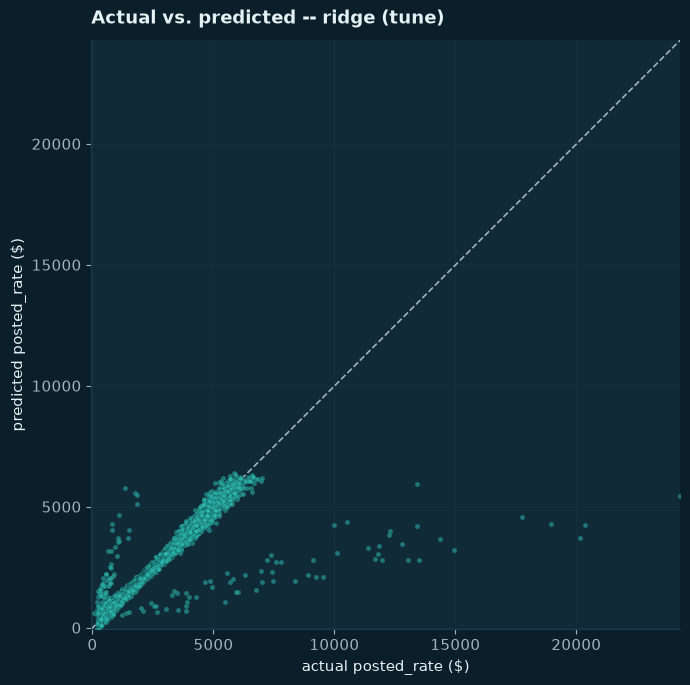

In [45]:
fig = viz.plot_actual_vs_predicted(
    y_tune, winner_pred, stage=STAGE, filename=f"{winner_name}_actual_vs_predicted.png",
    title=f"Actual vs. predicted -- {winner_name} (tune)",
)

INFO src.viz: Plotting residuals: Residuals -- ridge (tune) (n=9429)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\modeling\ridge_residuals.png


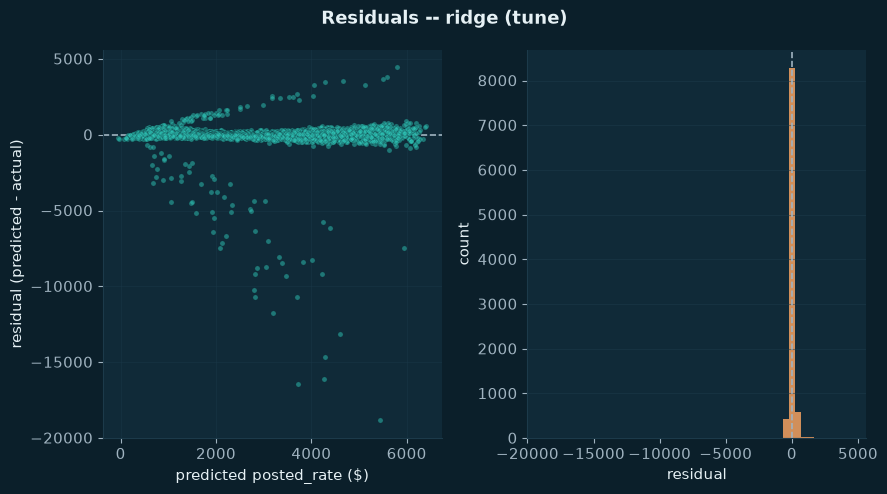

In [46]:
winner_resid = evaluate.residuals(y_tune, winner_pred)
fig = viz.plot_residuals(
    winner_pred, winner_resid, stage=STAGE, filename=f"{winner_name}_residuals.png",
    title=f"Residuals -- {winner_name} (tune)",
)

## Feature importance / SHAP for the winner

Coefficients for Ridge (if it wins), built-in feature importances for
any tree model, and SHAP specifically if a tree model wins -- SHAP's
`TreeExplainer` is fast and exact for tree ensembles, and directly
supports "why this rate for this load," the explanation a
non-technical user of a Spotter-style tool would actually want, not
just which features matter on average.

In [47]:
if winner_name == "ridge":
    ridge_model = fitted_models["ridge"].named_steps["model"]
    feature_names = (
        NUMERIC_FEATURES
        + list(fitted_models["ridge"].named_steps["preprocess"]
               .named_transformers_["categorical"].get_feature_names_out(CATEGORICAL_FEATURES))
    )
    coefficients = pd.Series(ridge_model.coef_, index=feature_names).sort_values(key=abs, ascending=False)
    print("Ridge coefficients (standardized numeric features, one-hot categorical):")
    print(coefficients)
elif winner_name == "knn":
    print("kNN has no native feature importance -- it's a non-parametric, distance-based method.")
else:
    # Random Forest, LightGBM, or HistGradientBoostingRegressor
    if winner_name == "hist_gradient_boosting":
        winner_model = fitted_models["hist_gradient_boosting"].named_steps["model"]
        X_shap = X_train_hgbr_imputed.sample(n=min(2000, len(X_train_hgbr_imputed)), random_state=42)
    else:
        winner_model = fitted_models[winner_name].named_steps["model"]
        preprocess = fitted_models[winner_name].named_steps["preprocess"]
        X_shap_raw = X_train.sample(n=min(2000, len(X_train)), random_state=42)
        X_shap = pd.DataFrame(
            preprocess.transform(X_shap_raw),
            columns=preprocess.get_feature_names_out(),
        )

    explainer = shap.TreeExplainer(winner_model)
    shap_values = explainer(X_shap)
    print(f"SHAP values computed on a {len(X_shap)}-row sample of train.")
    mean_abs_shap = pd.Series(
        np.abs(shap_values.values).mean(axis=0), index=X_shap.columns
    ).sort_values(ascending=False)
    print("\nMean |SHAP value| per feature (global importance):")
    print(mean_abs_shap)

Ridge coefficients (standardized numeric features, one-hot categorical):
distance               1103.044808
equipment_Reefer        278.628047
lane_target_enc         263.835527
equipment_Flatbed       179.949724
weight                   56.798866
day_of_year_cos         -44.989625
market_index             42.375107
quote_signal             19.180691
delivery_target_enc     -11.882597
day_of_year_sin          -4.610510
pickup_target_enc        -3.821932
dtype: float64


`distance` dominates by a wide margin (coefficient ≈1,103 on the
standardized scale, more than triple the next largest), matching
every prior notebook's finding (0.91 raw correlation with the target
back in EDA, the single strongest driver in the baseline model too) —
not a new finding, but a reassuring consistency check that Ridge's
coefficients agree with everything already established. `equipment`
comes through clearly and in the same sensible order EDA found
(Reefer +279, Flatbed +180, both relative to the dropped Dry Van
baseline category) — real, interpretable, and matches domain
intuition about refrigeration and specialized-freight costs.

The engineered features split in an interesting way: `lane_target_enc`
(+264) carries real, substantial weight — close to `equipment`'s
effect size — supporting `05_feature_engineering.ipynb`'s finding
that the lane feature carries information beyond the two city
encodings alone. But `pickup_target_enc` and `delivery_target_enc`
individually come out small (-3.8 and -11.9) — once `distance` and
`lane_target_enc` are already in the model, the two individual-city
encodings add little further linear signal, which is a sensible
result: a city's typical rate is largely explained by which lanes it
sits on and how far those lanes run, both already captured elsewhere
in the model. The two cyclical date features are small but nonzero
(`day_of_year_cos` -45, `day_of_year_sin` -4.6) — a real but modest
seasonal effect, consistent with EDA's ~10% peak-to-trough finding
rather than a dominant driver.

## Residual-based confidence bands

Not built into `validation_predictions.csv` or
`december_chart_inputs.csv` -- both are fixed two-column CSV formats
(`load_id,predicted_rate` / the seven original December columns) with
no room for a range, and the assessment scorer (`score.py`) validates
against that exact shape. This is deliberately built and demonstrated
here as a described capability for how the model's own uncertainty
would actually be surfaced in a real interface, alongside the
dashboard idea from the roadmap -- not something the graded
deliverable can carry.

Approach: bucket the winning model's `tune` predictions by predicted-
rate range (same idea as the quartile check in
`04_baseline_model.ipynb`), and report each bucket's empirical
residual spread. This generalizes to any of the five models (unlike
LightGBM-specific quantile regression), which matters since the
winner isn't fixed in advance.

In [48]:
def residual_confidence_bands(y_pred: np.ndarray, residual_values: np.ndarray, n_buckets: int = 5) -> pd.DataFrame:
    """
    Bucket predictions by predicted-value range and report each
    bucket's empirical residual spread -- a model-agnostic stand-in for
    a real prediction interval, usable with any of the five models
    compared in this notebook rather than requiring quantile-regression
    support specific to one of them.

    Args:
        y_pred: Predicted target values.
        residual_values: Residuals (predicted - actual), same
            length/order as y_pred.
        n_buckets: Number of predicted-value buckets.

    Returns:
        DataFrame indexed by bucket range, with columns "n",
        "mean_predicted", "residual_std", "band_lower_offset",
        "band_upper_offset" (±1 residual std, in dollars, to add to a
        new prediction landing in that bucket for an approximate range).
    """
    frame = pd.DataFrame({"predicted": y_pred, "residual": residual_values})
    frame["bucket"] = pd.qcut(frame["predicted"], n_buckets)
    summary = frame.groupby("bucket", observed=True).agg(
        n=("residual", "count"),
        mean_predicted=("predicted", "mean"),
        residual_std=("residual", "std"),
    )
    summary["band_lower_offset"] = -summary["residual_std"]
    summary["band_upper_offset"] = summary["residual_std"]
    return summary


confidence_bands = residual_confidence_bands(winner_pred, winner_resid)
confidence_bands.round(2)

,n,mean_predicted,residual_std,band_lower_offset,band_upper_offset
bucket,,,,,
"(-50.236999999999995, 1162.724]",1886,827.26,255.72,-255.72,255.72
"(1162.724, 1736.144]",1886,1450.67,288.69,-288.69,288.69
"(1736.144, 2403.988]",1885,2052.73,468.48,-468.48,468.48
"(2403.988, 3666.44]",1886,2963.18,749.06,-749.06,749.06
"(3666.44, 6411.401]",1886,4530.04,1019.27,-1019.27,1019.27


The pattern already anticipated back in `04_baseline_model.ipynb`'s
residual diagnostic is confirmed directly here on the winning model:
absolute residual spread grows steadily with predicted rate ($256 in
the cheapest bucket up to $1,019 in the priciest), roughly 4x — real
heteroscedasticity, not an artifact of one model or one notebook. But
the *relative* picture is what actually matters for how confident to
be in a given prediction: as a percentage of the predicted value, the
spread is worst in the cheapest bucket (30.9%) and comparatively
tighter everywhere else (19.9-25.3%) -- the same pattern that
explained Ridge's RMSE/MAPE split above. Practically: a dispatcher
should treat a low-dollar prediction from this tool with more
skepticism in percentage terms than a high-dollar one, even though
the high-dollar one carries a larger absolute dollar range. This
table -- bucket, mean prediction, ± residual std -- is exactly what a
future interface would show alongside each prediction, per the
discussion at the top of this notebook.

## Summary

**Split and search**: identical chronological split from
`src/config.py` for every model; `GridSearchCV` with `TimeSeriesSplit`
(never shuffled KFold) run on `train` only for hyperparameter
selection; `tune` is the independent comparison set; `test` (October)
stays untouched.

**Features**: the engineered feature set from
`05_feature_engineering.ipynb` (target-encoded `pickup`/`delivery`,
smoothed lane encoding, cyclical date features, plus the four original
numeric columns and one-hot `equipment`) for Ridge, Random Forest,
LightGBM, and kNN. `HistGradientBoostingRegressor` tested separately on
raw `pickup`/`delivery`/`equipment` categoricals instead of the encoded
versions — a direct test of whether native categorical handling makes
the encoding effort unnecessary for that model family.

**Result — no single winner across all three metrics, and that split
itself is the finding:**

| Model | RMSE | MAE | MAPE | R² |
|---|---|---|---|---|
| Ridge | **628.4** | 163.2 | 9.79% | 0.824 |
| HistGradientBoosting | 634.4 | **159.8** | 7.68% | 0.821 |
| LightGBM | 646.7 | 168.1 | **7.43%** | 0.814 |
| Random Forest | 671.6 | 188.4 | 8.19% | 0.799 |
| kNN | 734.0 | 355.5 | 25.59% | 0.760 |

Ridge wins RMSE. LightGBM and HistGradientBoostingRegressor both
clearly beat Ridge on MAPE. HistGradientBoostingRegressor now also
clearly beats Ridge on MAE (159.8 vs. 163.2), a gap that widened once
this notebook's grids were expanded — the original narrow-grid run had
these two essentially tied. Traced to the same mechanism as before:
Ridge's relative error is worst on the cheapest loads (30.9% of
predicted value, vs. 19.9-25.6% everywhere else), which costs it on
MAPE without costing it on RMSE. kNN's last-place finish across every
metric is the expected result for the deliberate sanity-check inclusion.

**Widening the grids moved the tree models closer to Ridge but didn't
change the winner.** Random Forest improved the most (RMSE 695.4 →
671.6) once `min_samples_leaf` was actually searched — that parameter
was completely untested in the original run, and it turned out to
matter. LightGBM and HistGradientBoostingRegressor both improved more
modestly. Ridge's own RMSE barely moved (628.4 → 628.4) since its
winning `alpha=100` was already inside the original grid's range — the
wider 9-value sweep confirmed rather than changed that result, which is
itself useful: it means Ridge's original win wasn't an artifact of an
under-searched alpha.

**Practical recommendation**: `hist_gradient_boosting`, not the
RMSE-sorted `ridge`. It now sits within 1.0% of Ridge's RMSE (tighter
than the original run's 1.3%) while clearly winning both MAPE and MAE
— a more unambiguous case for balance across all three metrics than
the original run had, since the MAE tie has resolved in its favor.
Ridge remains the interpretability anchor and a strong, close second —
not a discarded model.

**Interpretability and confidence, addressed as planned**: Ridge's
coefficients confirm the same story as the original run — `distance`
dominates (1103.0, more than triple the next largest), `equipment`
behaves sensibly (Reefer +278.6, Flatbed +179.9), `lane_target_enc`
carries real standalone weight (+263.8), while the individual city
encodings (`pickup_target_enc` -3.8, `delivery_target_enc` -11.9)
contribute little once lane and distance are already in the model.
Residual-based confidence bands are essentially unchanged from the
original run (cheapest bucket 30.9% of predicted value vs. 19.9-25.6%
elsewhere) — this pattern held even after the grid search widened,
which is further evidence it's a real property of the data, not a
narrow-grid artifact.

**Superseded by `07_model_comparison.ipynb`**: this notebook only ever
tested Ridge's regularization *strength*, never its *type* — Lasso
(L1) and Elastic Net (L1/L2 blend) were absent from the model menu
entirely, and Ridge's own confidence-band pattern (worse relative error
on cheap loads) suggested ordinary-least-squares sensitivity to
high-residual rows was worth testing directly via a robust-loss model.
`07` tests exactly that and finds **Huber regression beats every model
in both notebooks outright** — lower RMSE than Ridge (624.4 vs. 628.4),
lower MAE than every model here including `hist_gradient_boosting`
(145.8 vs. 159.8), and MAPE that essentially ties the best tree result
here (7.68% vs. `hist_gradient_boosting`'s 7.68%). **The practical
recommendation above is superseded — see `07`'s Summary for the actual
model carried into `validation_predictions.csv` and
`december_chart_inputs.csv`.**